unsupervised ml input hoy output nai,complex math

pca converts higher dimension to lower dimension keeping essence of data same i.e behaviour of data ne same rakhe so ml algo kaam kare to results sara j aave in low dimension

ADV:
1. high to low dimension so data nu size small so ml algo runs/execute faster so comuptation bache
2. visualization improves


to select which col to keep aapde scatter plot karsu and data no spread/variance j col na axis pr vadhare ae rakhvano --> thats how feature selection works

have agar banne pr same variance che
then--> feature extraction
to let say data has no.of rooms,no. of washrooms and price

so bane input cols are equally imp so we will count sq feet area and reducr cols --> feature scaling will not help feature extraction would

PCA does this ae data na features ne na rakhe complete new features banave from original and then ae subset ne rakhe j savthi imp hoy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.shape

(42000, 785)

In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
9182,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


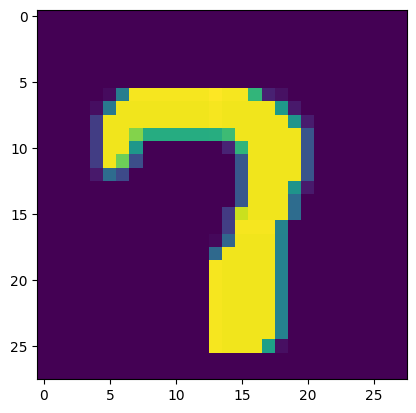

In [5]:
plt.imshow(df.iloc[6694,1:].values.reshape(28,28)) # 2d ne 1d ma karyu convert

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state = 0)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn = KNeighborsClassifier()

In [10]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time()-start)

26.736721992492676


In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9657142857142857

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100) #ketla dimensions banse if none to original jetla j reh

In [16]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [17]:
X_train.shape

(29400, 784)

In [18]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)
y_pred = knn.predict(X_test_trf)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9497619047619048

In [ ]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred = knn.predict(X_test_trf)
    print(accuracy_score(y_test,y_pred))